# 의사결정나무 (Decision Tree)
1. **정의** : 데이터를 조건에 따라 분기하면서, 트리 형태로 분류하거나 예측하는 알고리즘이며 스무고개 게임과 유사하다.

2. **주요 용어**

| 용어 | 설명 |
| --- | --- |
| 루트 노드 | 최상단 노드 |
| 내부 노드 | 중간 분기 노드 |
| 리프 노드 | 최종 결과 | 
| 깊이 | 루트에서 리프까지의 길이|

3. **분기 기준**
    - 클래스 비율 : p = 특정 클래스의 데이터 개수 / 전체 클래스의 데이터 개수
    - 지니 불순도 : $Gini = 1 - \sum_{i=1}^{k} p_i^2$
    - 엔트로피 : $Entropy = -\sum_{i=1}^{k} p_{i} \log_{2}{p_{i}}$
    - 정보이득 : $IG = H(parent) - \sum \frac{n_{child}}{n_{parent}} H(child)$
    - 불순도가 낮을수록 한쪽 클래스로 잘 나뉘었다는 뜻이다.

/var/folders/x2/_ysblkzj38n3zryb8y5w9kz40000gn/T/ipykernel_88429/2180342224.py:7: RuntimeWarning: divide by zero encountered in log2
  entropy = - (p * np.log2(p) + (1-p) * np.log2(1-p))
/var/folders/x2/_ysblkzj38n3zryb8y5w9kz40000gn/T/ipykernel_88429/2180342224.py:7: RuntimeWarning: invalid value encountered in multiply
  entropy = - (p * np.log2(p) + (1-p) * np.log2(1-p))


Text(0.5, 1.0, 'Entropy')

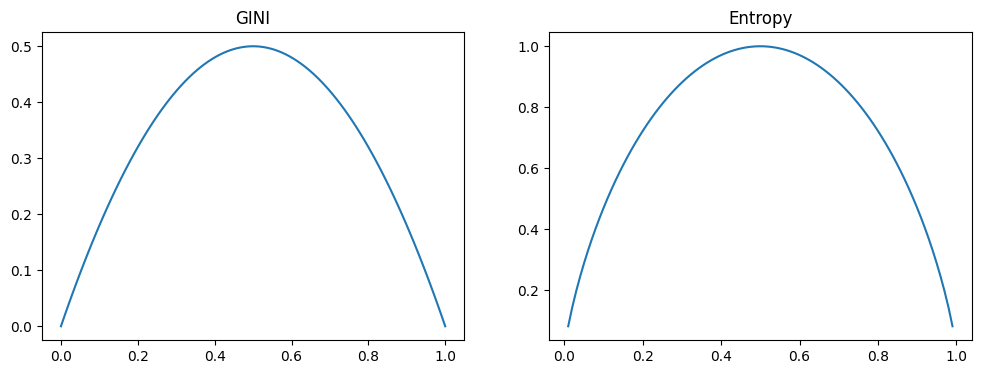

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = np.linspace(0, 1, 100)
gini = 1 - (p ** 2 + (1-p) ** 2)
entropy = - (p * np.log2(p) + (1-p) * np.log2(1-p))

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(p, gini)
axes[0].set_title("GINI")

axes[1].plot(p, entropy)
axes[1].set_title("Entropy")


## 그럼 분기 과정은 어떻게 되는가?
1. 데이터의 중간 값으로 분기한다. -> X = [10, 20, 30, 40, 50]이라면 15, 25, 35, 45로 나눠본다.

2. 그 중에 정보이득이 제일 큰 조건으로 분기한다.

3. 이 과정을 반복하여 설정한 depth까지 분기한다. -> depth를 설정하지 않았다면 불순도가 0이 될 때까지 분기하지만 과적합이 되기 쉽다.

## 데이터 생성

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

data = {
    "키": [160, 165, 170, 155, 175, 180, 158, 172, 168, 185],
    "몸무게": [50, 60, 65, 45, 80, 85, 55, 70, 90, 75],
    "체형": ["마름", "보통", "보통", "마름", "비만", "비만", "마름", "보통", "비만", "보통"]
}

df = pd.DataFrame(data)
df


,키,몸무게,체형
0,160,50,마름
1,165,60,보통
2,170,65,보통
3,155,45,마름
4,175,80,비만
5,180,85,비만
6,158,55,마름
7,172,70,보통
8,168,90,비만
9,185,75,보통


## 간단한 의사결정나무 코드
분기 조건을 찾는 과정을 코드로 표현했다.

실제로는 이 과정을 계속 반복해 사용자가 설정한 depth 혹은 불순도가 0이 될 때까지 반복한다.

In [18]:
def gini(y):
    n = len(y)
    if n == 0:
        return 0
    classes = y.unique()
    result = 1
    for c in classes:
        p = len(y[y == c]) / n
        result -= p ** 2
    return result

def decision_tree(X, y):
    best_ig = 0
    best_cond = None

    for feature in X.columns:
        sorted_values = sorted(X[feature].unique())  # 정렬
        for i in range(len(sorted_values) - 1):
            threshold = (sorted_values[i] + sorted_values[i+1]) / 2  # 중간값

            left = y[X[feature] <= threshold]
            right = y[X[feature] > threshold]

            parent_gini = gini(y)
            child_gini = (len(left)/len(y)) * gini(left) + (len(right)/len(y)) * gini(right)

            ig = parent_gini - child_gini

            if ig > best_ig:
                best_ig = ig
                best_cond = (feature, threshold)

    return best_cond, best_ig


In [19]:
X = df.drop("체형", axis = 1)
y = df["체형"]

cond, ig = decision_tree(X, y)
print(cond, ig)

('몸무게', np.float64(77.5)) 0.31714285714285717


## Sklearn으로 의사결정나무 구현

In [24]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

In [21]:
data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7)

In [23]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9333333333333333


## 트리 그려보기
sklearn의 plot_tree라는 라이브러리를 사용하면 트리를 볼 수 있다.

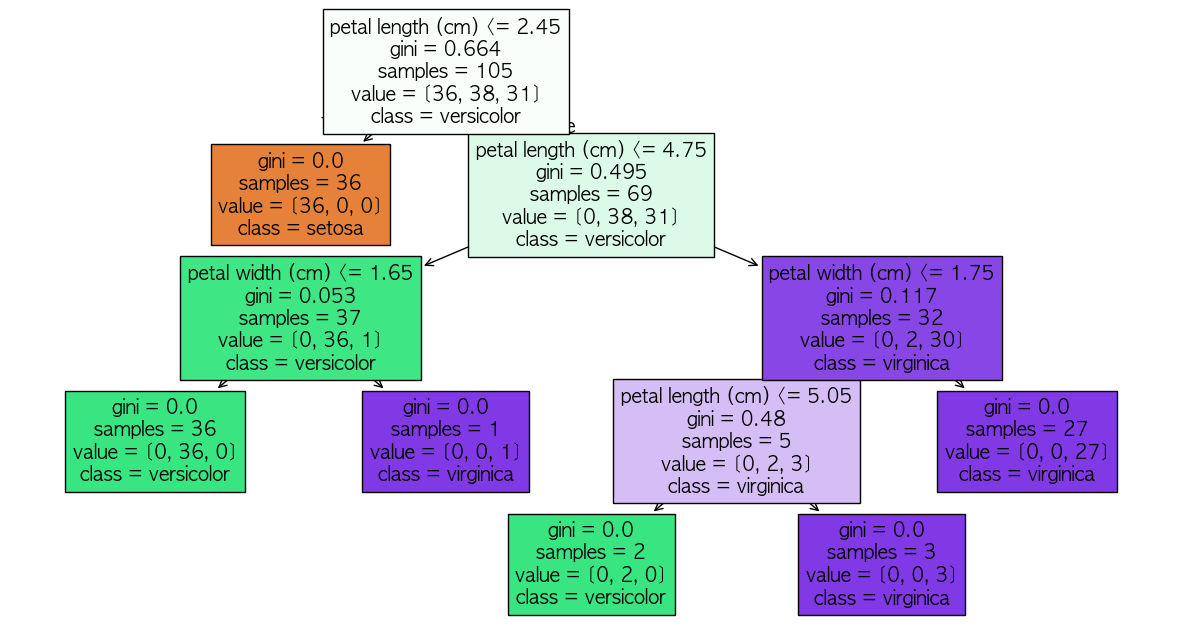

In [26]:
plt.figure(figsize = (15, 8))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()